# EDA on cleaned data

Analysis of `data/data_cleaned.csv` produced by `clean-feature-engineer.py`.
Focus: feature distributions after cleaning, feature-severity relationships relevant
to modeling, class imbalance, and feature selection rationale.

Casualty columns were dropped from this dataset because cross-tab analysis showed
their severity distribution is nearly identical across all category values (see
EDA_raw.ipynb for the raw cross-tab).

Color convention: Fatal injury = red, Serious Injury = yellow, Slight Injury = green.


## Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]
SEVERITY_COLORS = {
    "Slight Injury":  "#2ca02c",
    "Serious Injury": "#f1c40f",
    "Fatal injury":   "#d62728",
}
SEVERITY_PALETTE = [SEVERITY_COLORS[s] for s in SEVERITY_ORDER]


In [2]:
def severity_crosstab(s, target):
    pivot = pd.crosstab(s, target)
    for col in SEVERITY_ORDER:
        if col not in pivot.columns:
            pivot[col] = 0
    return pivot[SEVERITY_ORDER]


def plot_count_and_pct(series, target, title, order=None, rotation=0, figsize=(12, 4)):
    pivot = severity_crosstab(series, target)
    if order is not None:
        pivot = pivot.reindex([o for o in order if o in pivot.index])

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    pivot.plot(kind="bar", stacked=True, color=SEVERITY_PALETTE, ax=axes[0])
    axes[0].set_title(f"{title} — count")
    axes[0].set_ylabel("Number of accidents")
    axes[0].tick_params(axis="x", rotation=rotation)
    axes[0].grid(axis="y", linestyle="--", alpha=0.4)

    pct = pivot.div(pivot.sum(axis=1).replace(0, np.nan), axis=0)
    pct.plot(kind="bar", stacked=True, color=SEVERITY_PALETTE, ax=axes[1])
    axes[1].set_title(f"{title} — percentage")
    axes[1].set_ylabel("Share within group")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=rotation)
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].get_legend().remove()
    axes[1].legend(handles, labels, title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## Load and overview

In [3]:
df = pd.read_csv("data/data_cleaned.csv")
target = df["Accident_severity"]
print("shape:", df.shape)
print("NaN anywhere:", df.isna().sum().sum())
df.head(3)

shape: (12316, 32)
NaN anywhere: 0


,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Cause_of_accident,Accident_severity,Hour,TimeOfDay,RushHour,IsWeekend,Age_band_of_driver_ord,Driving_experience_ord,Service_year_of_vehicle_ord,Educational_level_ord,Severity_code
0,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,Residential areas,Unknown,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,Moving Backward,Slight Injury,17,Afternoon,1,0,1,2,4,5,0
1,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,Overtaking,Slight Injury,17,Afternoon,1,0,2,5,3,3,0
2,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41-100Q),Owner,Unknown,Recreational areas,Other,Unknown,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Changing lane to the left,Serious Injury,17,Afternoon,1,0,1,2,-1,3,1


In [4]:
# Full column summary after pipeline.
summary = []
for col in df.columns:
    s = df[col]
    if s.dtype.kind in ("i", "f"):
        rng = f"min={s.min()}, max={s.max()}, mean={s.mean():.2f}"
    else:
        top = ", ".join(s.value_counts().head(4).index.astype(str))
        rng = top
    summary.append({"column": col, "dtype": str(s.dtype),
                    "n_unique": s.nunique(), "sample": rng})
pd.DataFrame(summary)

,column,dtype,n_unique,sample
0,Day_of_week,str,7,"Friday, Thursday, Wednesday, Tuesday"
1,Age_band_of_driver,str,5,"18-30, 31-50, Over 51, Unknown"
2,Sex_of_driver,str,3,"Male, Female, Unknown"
3,Educational_level,str,7,"Junior high school, Elementary school, High sc..."
4,Vehicle_driver_relation,str,4,"Employee, Owner, Unknown, Other"
5,Driving_experience,str,7,"5-10yr, 2-5yr, Above 10yr, 1-2yr"
6,Type_of_vehicle,str,18,"Automobile, Lorry (41-100Q), Other, Unknown"
7,Owner_of_vehicle,str,5,"Owner, Governmental, Unknown, Organization"
8,Service_year_of_vehicle,str,6,"Unknown, 2-5yrs, Above 10yr, 5-10yrs"
9,Area_accident_occured,str,12,"Other, Office areas, Residential areas, Church..."


## Target distribution and class imbalance

Fatal injury is 1.3% of the data — about 65x rarer than Slight Injury.
Any classifier trained without imbalance handling will almost certainly ignore the
Fatal class entirely. Recommended strategy: SMOTE on the training fold only
(never on the full dataset before splitting).


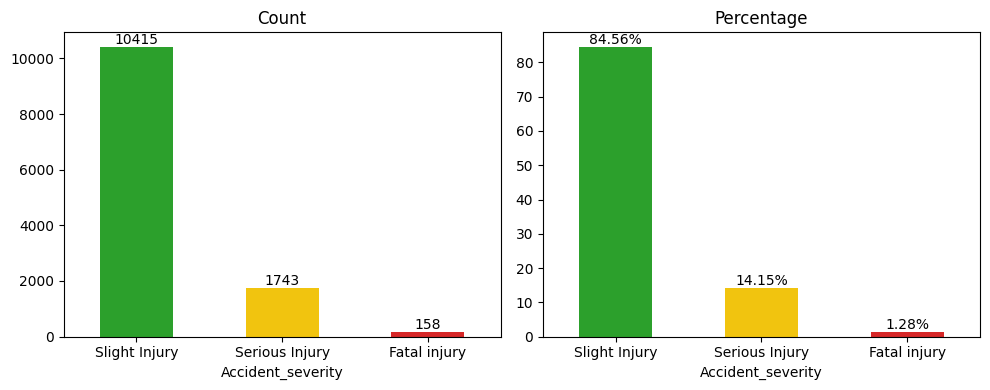

Imbalance ratio (Slight / Fatal): 66x


In [5]:
counts = target.value_counts().reindex(SEVERITY_ORDER)
pct = (counts / counts.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts.plot(kind="bar", color=SEVERITY_PALETTE, ax=axes[0])
axes[0].set_title("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

pct.plot(kind="bar", color=SEVERITY_PALETTE, ax=axes[1])
axes[1].set_title("Percentage")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(pct):
    axes[1].text(i, v, f"{v}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance ratio (Slight / Fatal): {imbalance_ratio:.0f}x")

## Feature-severity relationships

Percentage plots are more useful than count plots here — Fatal is so rare that
it is invisible on a count scale. The percentage view shows which categories
shift the Fatal/Serious share most.


### Time

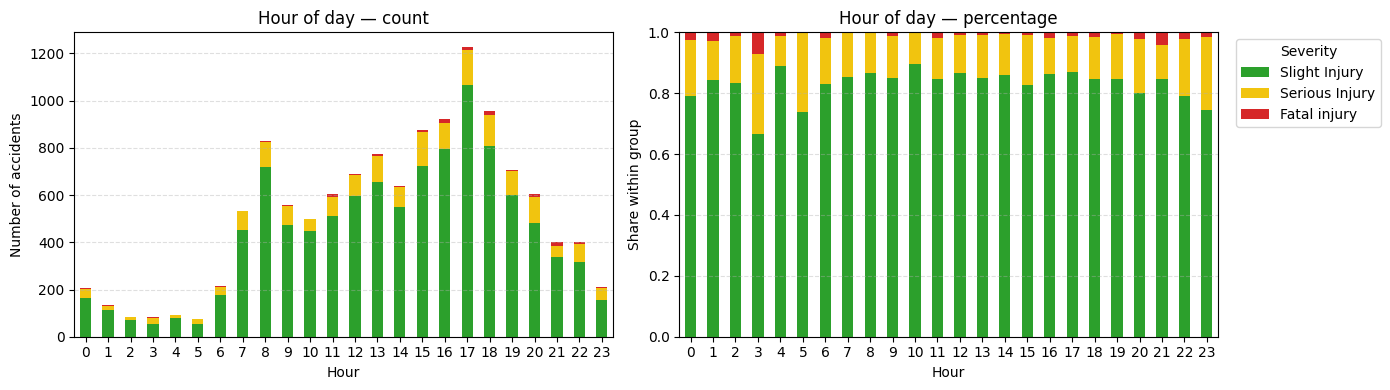

In [6]:
plot_count_and_pct(df["Hour"], target, "Hour of day", figsize=(14, 4))

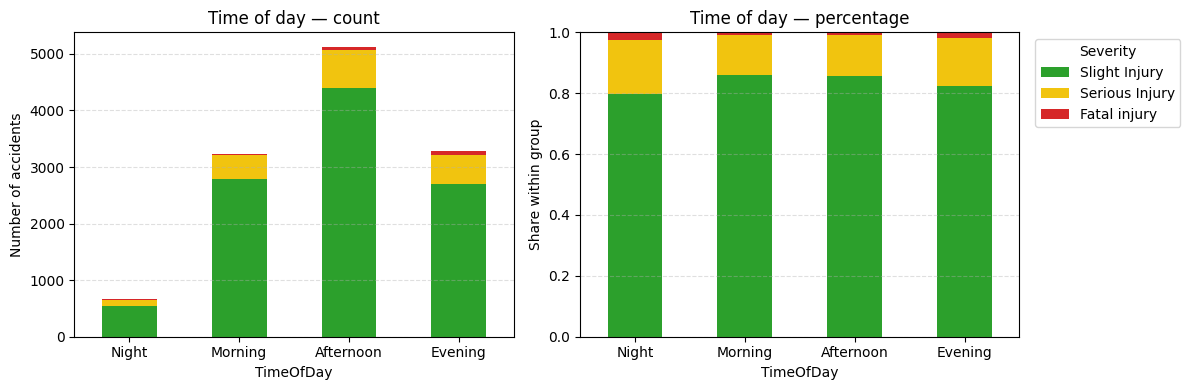

In [7]:
plot_count_and_pct(df["TimeOfDay"], target, "Time of day",
                   order=["Night", "Morning", "Afternoon", "Evening"])

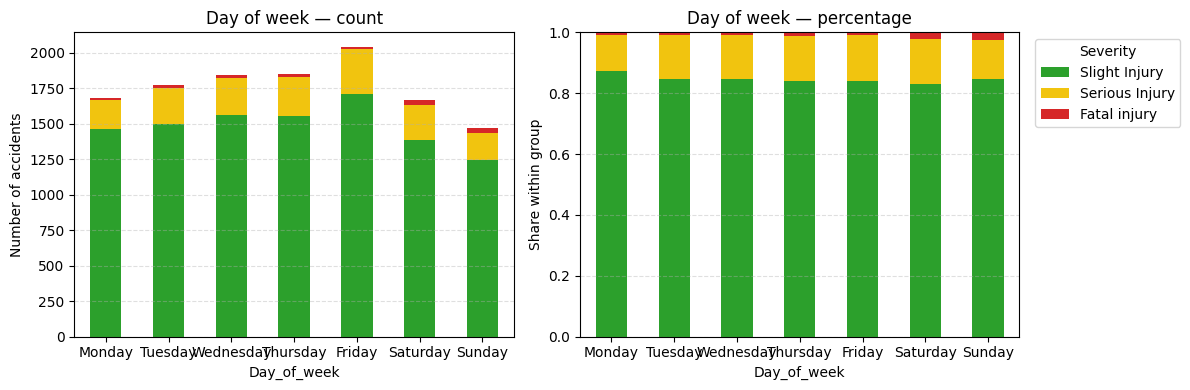

In [8]:
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plot_count_and_pct(df["Day_of_week"], target, "Day of week", order=DAY_ORDER)

### Driver

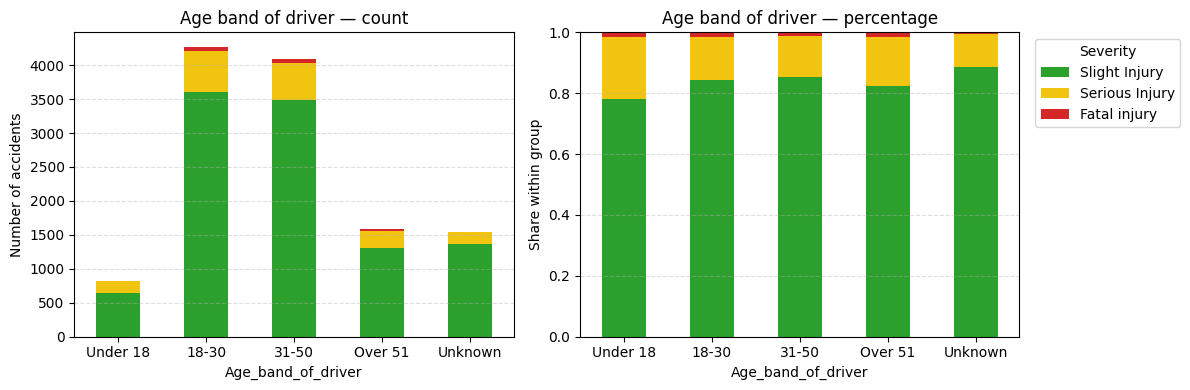

In [9]:
plot_count_and_pct(df["Age_band_of_driver"], target, "Age band of driver",
                   order=["Under 18", "18-30", "31-50", "Over 51", "Unknown"])

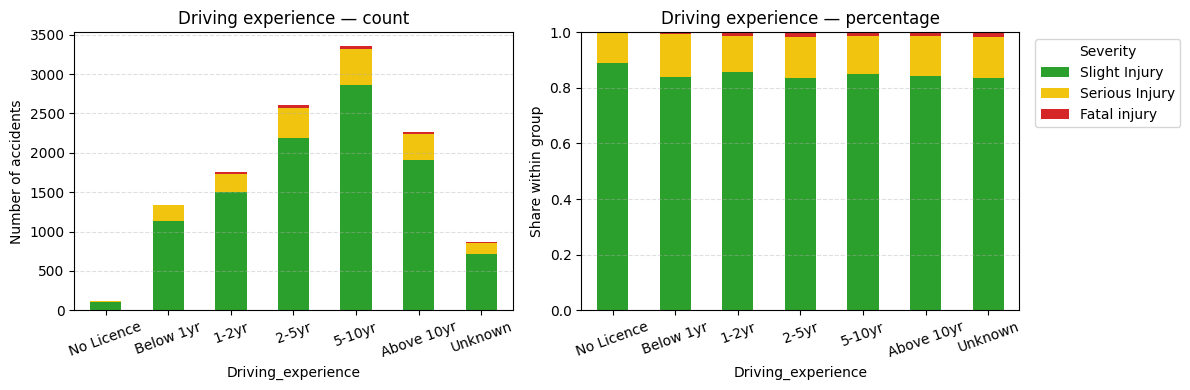

In [10]:
EXP_ORDER = ["No Licence", "Below 1yr", "1-2yr", "2-5yr", "5-10yr", "Above 10yr", "Unknown"]
plot_count_and_pct(df["Driving_experience"], target,
                   "Driving experience", order=EXP_ORDER, rotation=20)

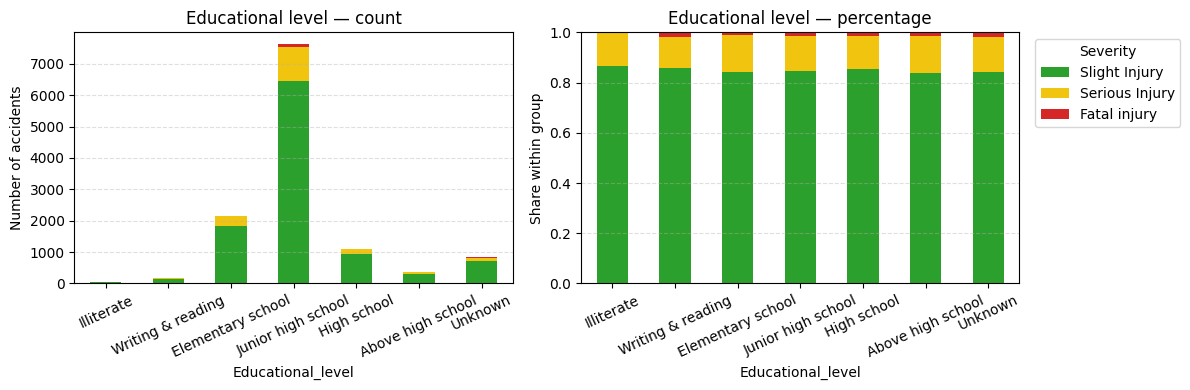

In [11]:
EDU_ORDER = ["Illiterate", "Writing & reading", "Elementary school",
             "Junior high school", "High school", "Above high school", "Unknown"]
plot_count_and_pct(df["Educational_level"], target,
                   "Educational level", order=EDU_ORDER, rotation=25)

### Vehicle and road

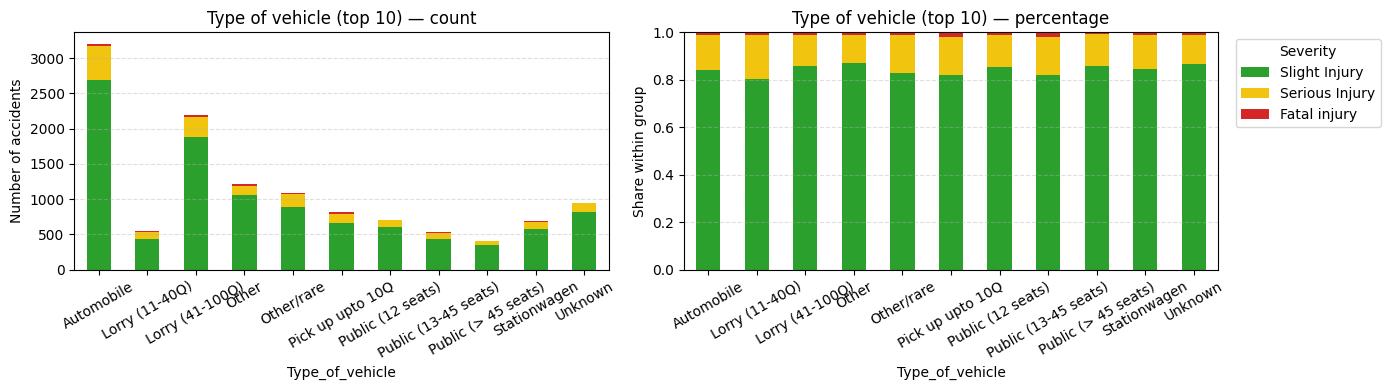

In [12]:
top_types = df["Type_of_vehicle"].value_counts().head(10).index
plot_count_and_pct(
    df["Type_of_vehicle"].where(df["Type_of_vehicle"].isin(top_types), "Other/rare"),
    target, "Type of vehicle (top 10)", rotation=30, figsize=(14, 4))

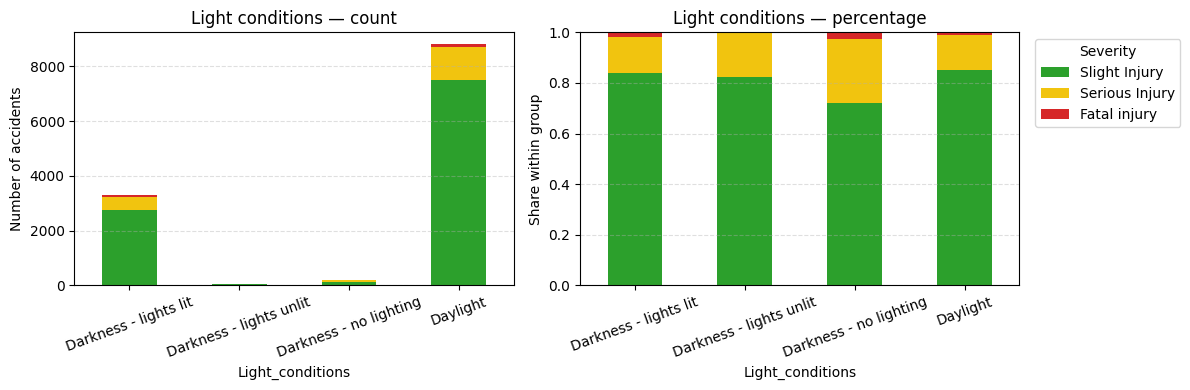

In [13]:
plot_count_and_pct(df["Light_conditions"], target, "Light conditions", rotation=20)

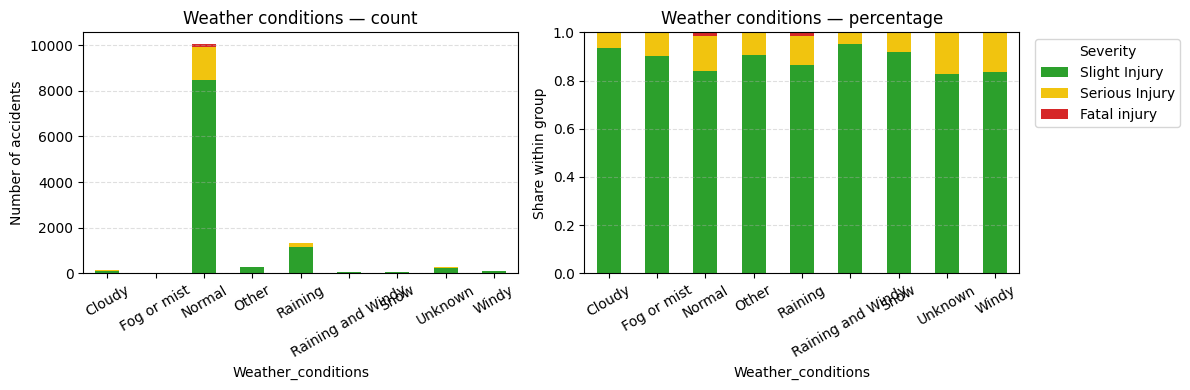

In [14]:
plot_count_and_pct(df["Weather_conditions"], target, "Weather conditions", rotation=30)

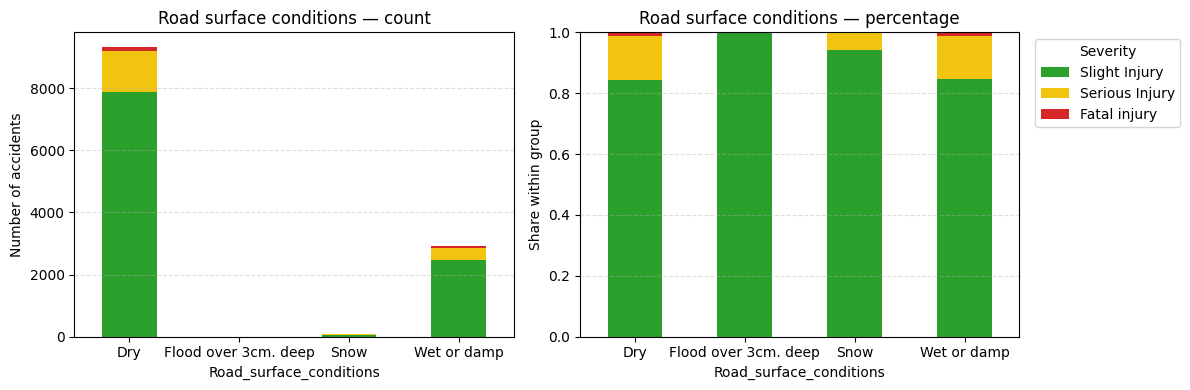

In [15]:
plot_count_and_pct(df["Road_surface_conditions"], target, "Road surface conditions")

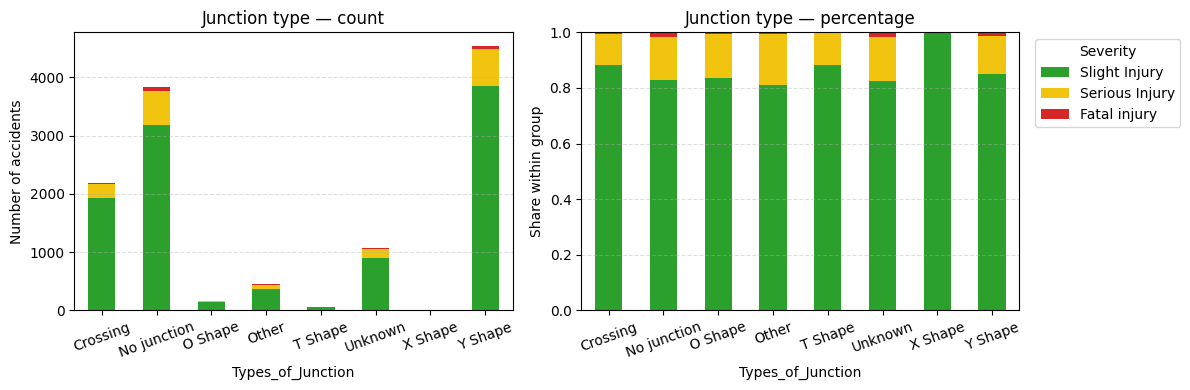

In [16]:
plot_count_and_pct(df["Types_of_Junction"], target, "Junction type", rotation=20)

### Collision

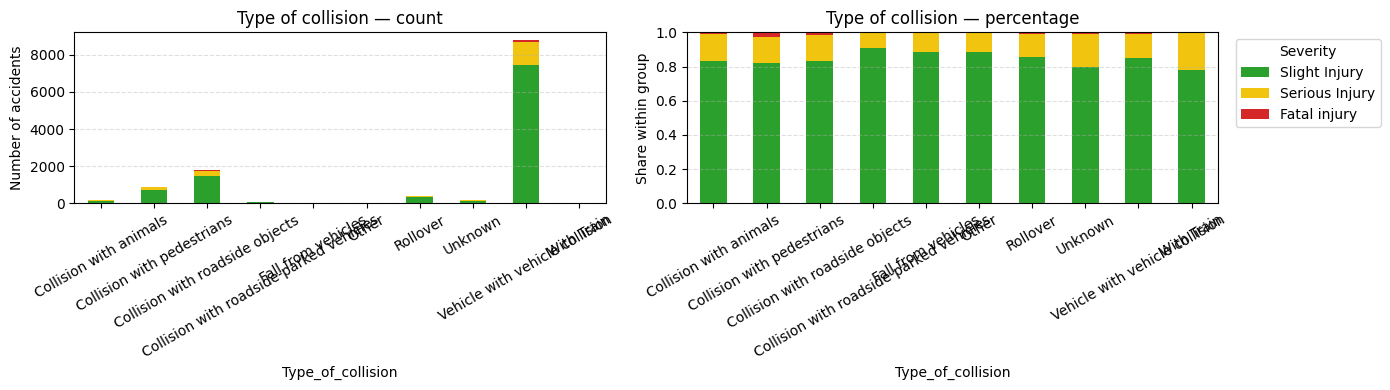

In [17]:
plot_count_and_pct(df["Type_of_collision"], target,
                   "Type of collision", rotation=30, figsize=(14, 4))

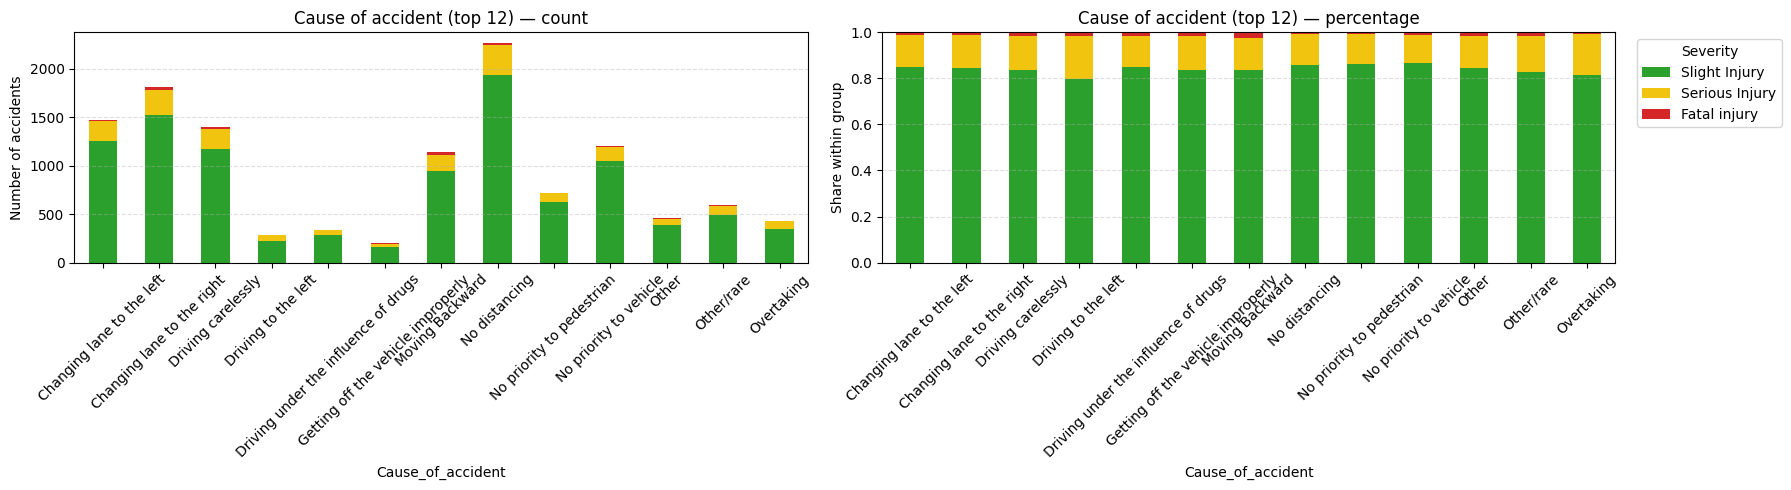

In [27]:
cause_top = df["Cause_of_accident"].value_counts().head(12).index
plot_count_and_pct(
    df["Cause_of_accident"].where(df["Cause_of_accident"].isin(cause_top), "Other/rare"),
    target, "Cause of accident (top 12)", rotation=45, figsize=(18, 5))

## Numeric feature distributions

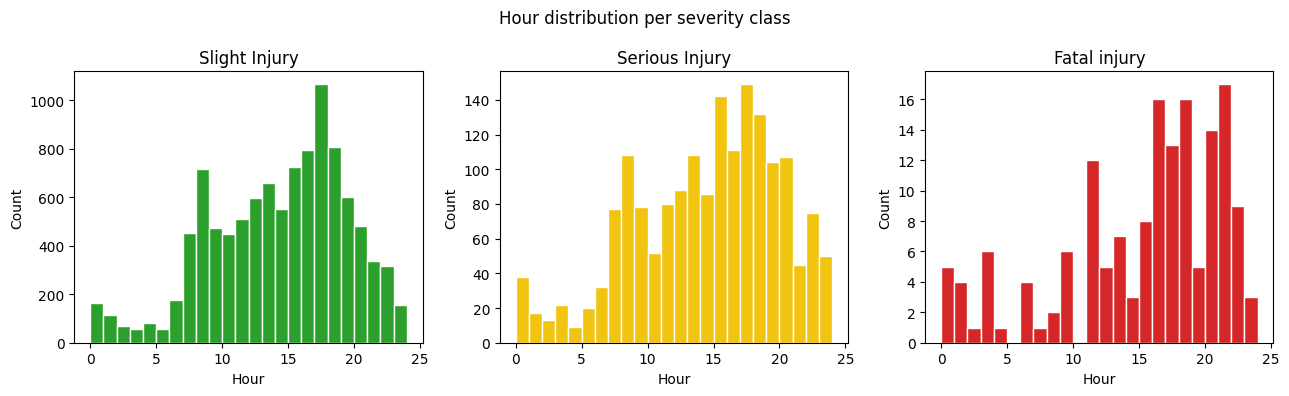

In [19]:
# Hour distribution by severity — violin or box is better than a bar here.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, sev, color in zip(axes, SEVERITY_ORDER, SEVERITY_PALETTE):
    mask = target == sev
    axes_list = df.loc[mask, "Hour"]
    ax.hist(axes_list, bins=24, range=(0, 24), color=color, edgecolor="white")
    ax.set_title(sev)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Count")
plt.suptitle("Hour distribution per severity class")
plt.tight_layout()
plt.show()

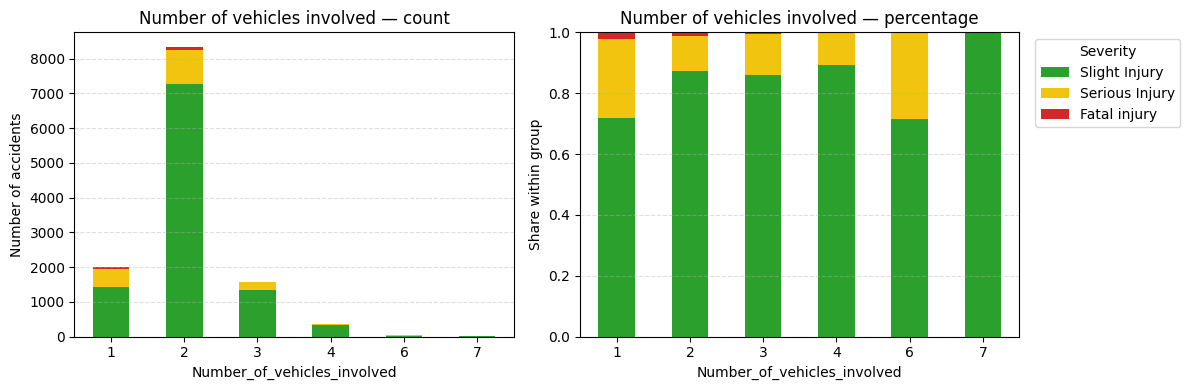

In [20]:
plot_count_and_pct(df["Number_of_vehicles_involved"], target,
                   "Number of vehicles involved")

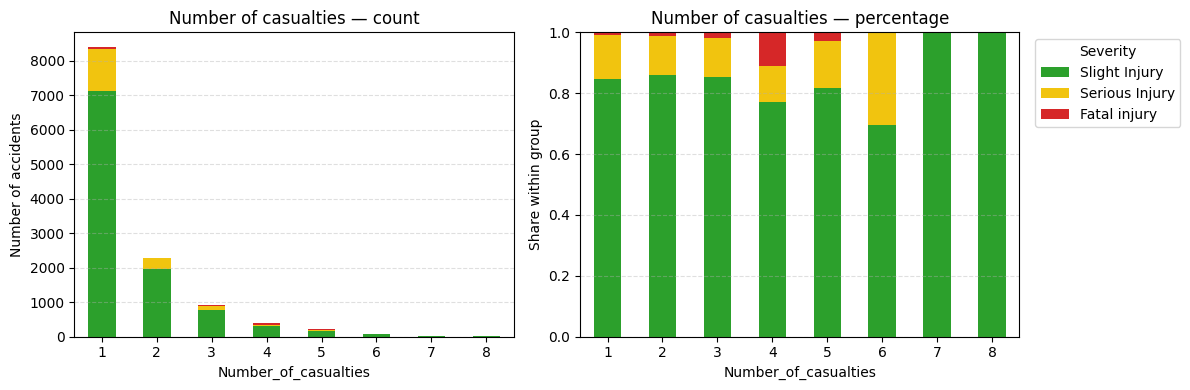

In [21]:
plot_count_and_pct(df["Number_of_casualties"], target,
                   "Number of casualties")

## Ordinal engineered features

The `_ord` columns encode ordered categories as integers (-1 = Unknown/not on scale).
These give models a numeric handle on ordinal relationships that OHE cannot capture.


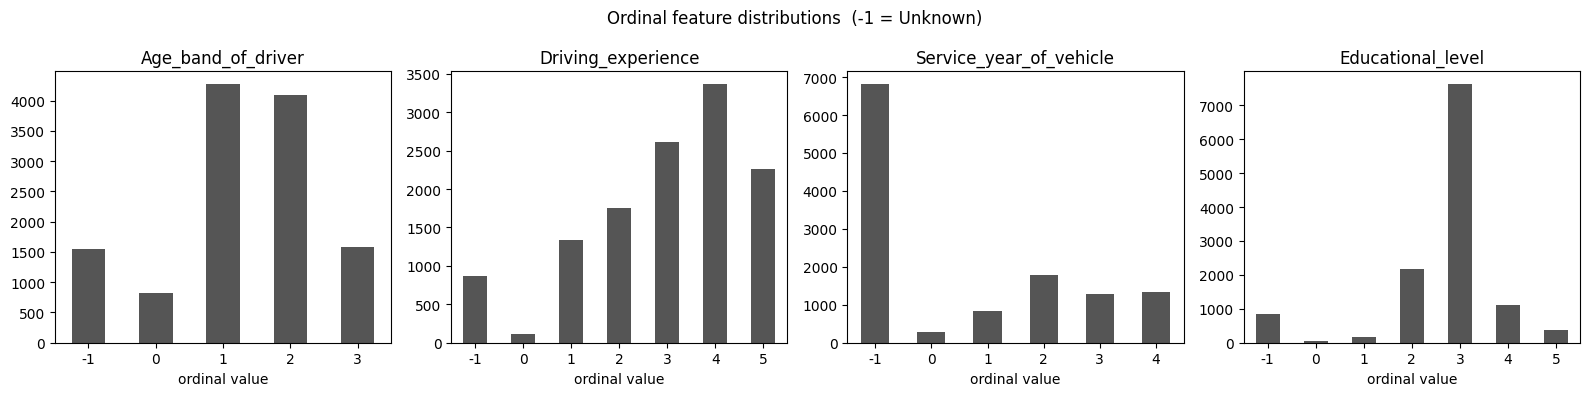

In [22]:
ord_cols = [c for c in df.columns if c.endswith("_ord")]
fig, axes = plt.subplots(1, len(ord_cols), figsize=(16, 4))
for ax, col in zip(axes, ord_cols):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="#555")
    ax.set_title(col.replace("_ord", ""))
    ax.set_xlabel("ordinal value")
    ax.tick_params(axis="x", rotation=0)
plt.suptitle("Ordinal feature distributions  (-1 = Unknown)")
plt.tight_layout()
plt.show()

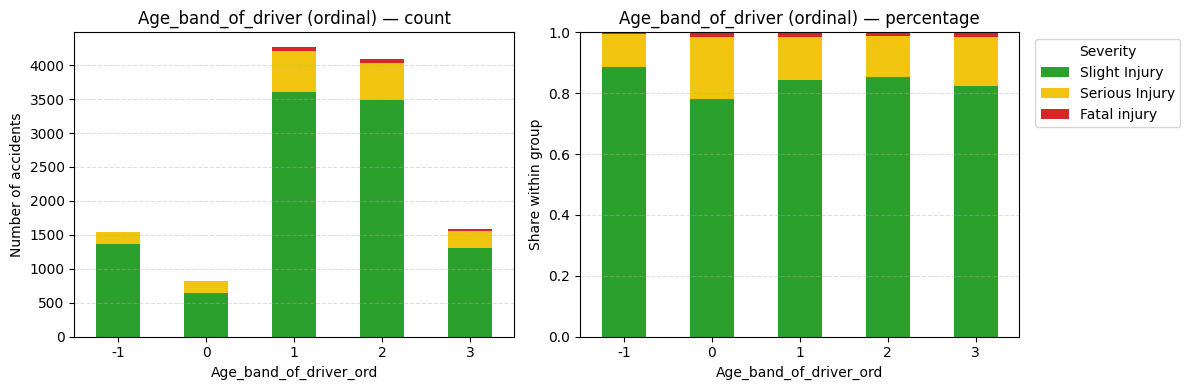

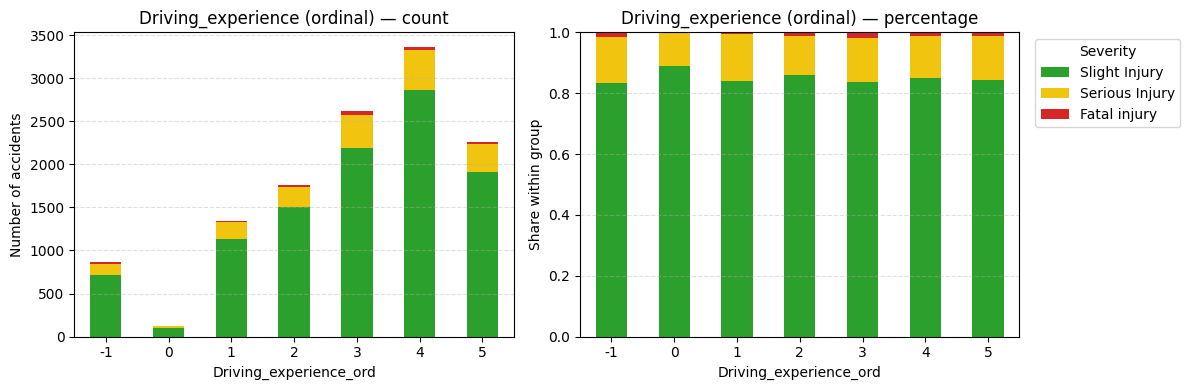

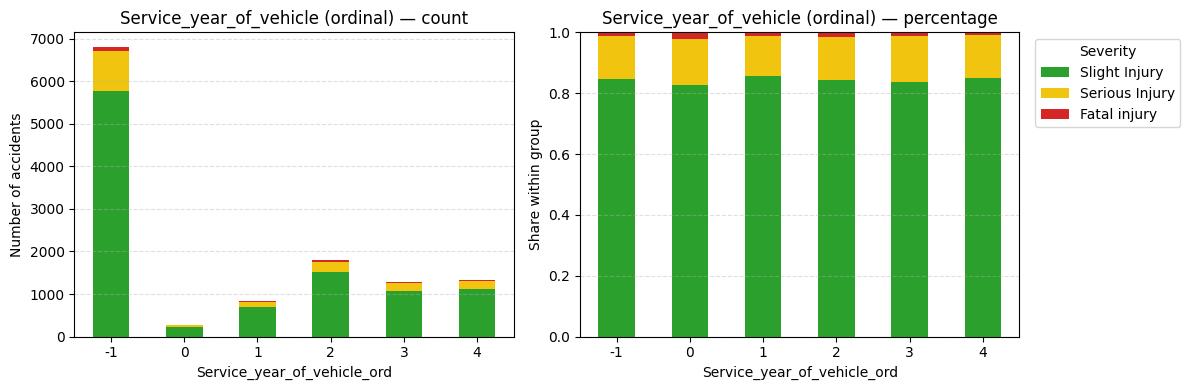

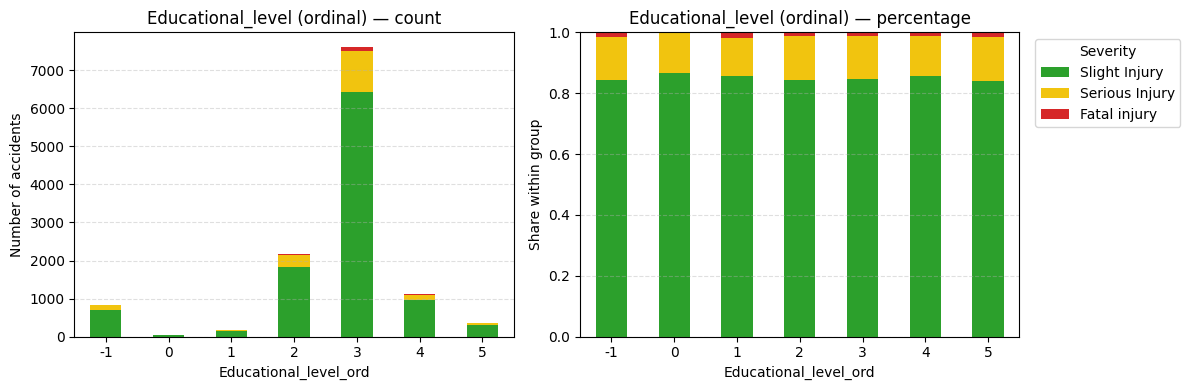

In [23]:
# Ordinal value vs severity — does the ordinal ranking track risk?
for col in ord_cols:
    plot_count_and_pct(df[col], target, col.replace("_ord", "") + " (ordinal)")

## Correlation among numeric features

Only numeric columns (including ordinal codes). Useful for spotting redundancy
before model selection.


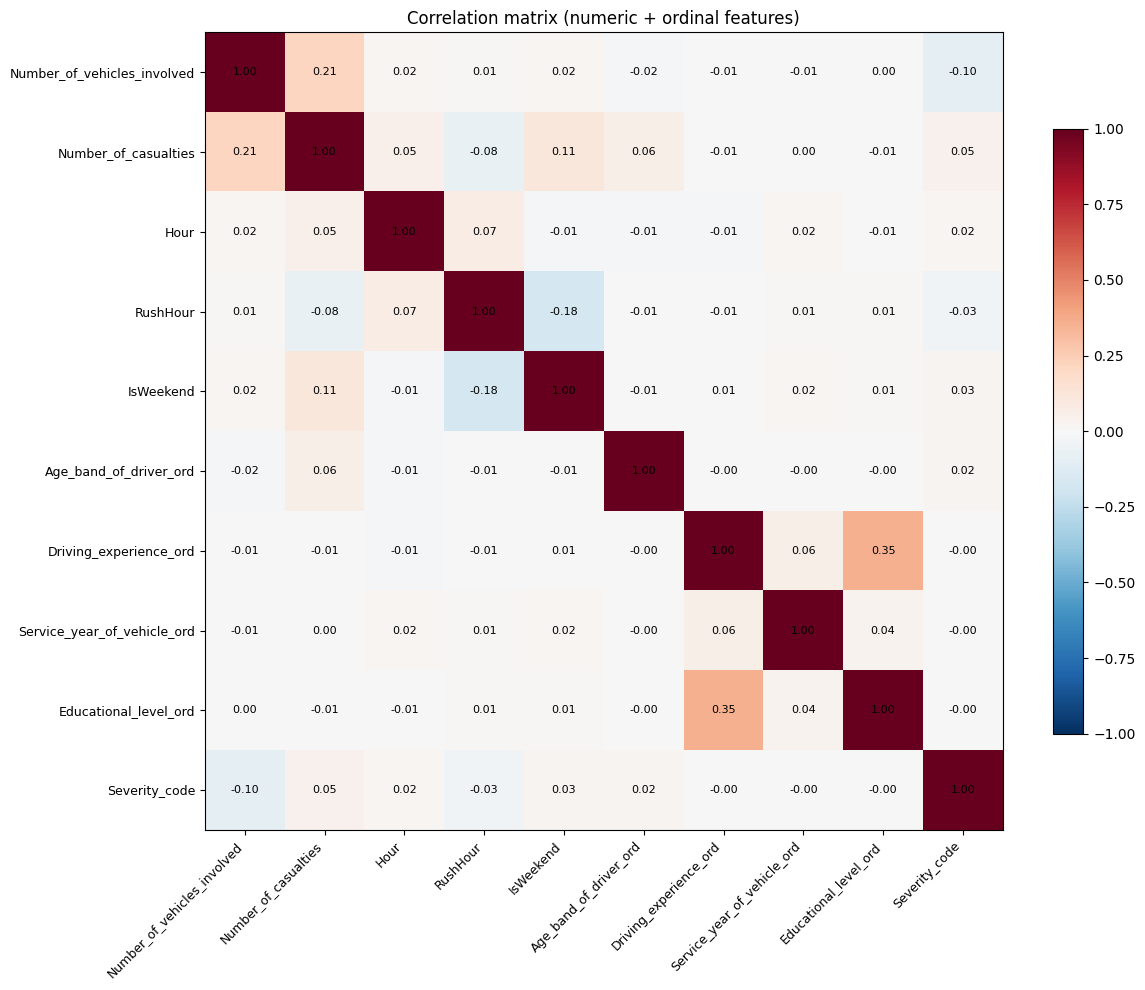

Correlations with Severity_code:
Number_of_vehicles_involved   -0.096
Number_of_casualties           0.045
RushHour                      -0.033
IsWeekend                      0.025
Age_band_of_driver_ord         0.024
Hour                           0.018
Educational_level_ord         -0.004
Driving_experience_ord        -0.002
Service_year_of_vehicle_ord   -0.000
Name: Severity_code, dtype: float64


In [28]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Exclude the target code itself from the correlation heatmap inputs.
corr_cols = [c for c in num_cols if c != "Severity_code"]

corr = df[corr_cols + ["Severity_code"]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title("Correlation matrix (numeric + ordinal features)")
plt.tight_layout()
plt.show()

# Top correlations with Severity_code.
sev_corr = corr["Severity_code"].drop("Severity_code").sort_values(key=abs, ascending=False)
print("Correlations with Severity_code:")
print(sev_corr.round(3))

## Cramér's V (categorical–categorical association)

Pearson correlation only covers the 10 numeric/ordinal columns. For the 18 categorical
features, Cramér's V (bias-corrected, Bergsma & Wicher 2013) gives a 0–1 association
strength derived from the chi-squared statistic. Useful for:

- spotting redundant categorical pairs that encode the same information,
- ranking which categorical features carry the most signal against `Accident_severity`.

The four string columns whose `_ord` versions exist (`Age_band_of_driver`,
`Driving_experience`, `Service_year_of_vehicle`, `Educational_level`) are excluded here
because the modeling notebooks drop them in favor of their ordinal twins.


/tmp/ipykernel_25318/3043241743.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  c for c in df.select_dtypes(include="object").columns


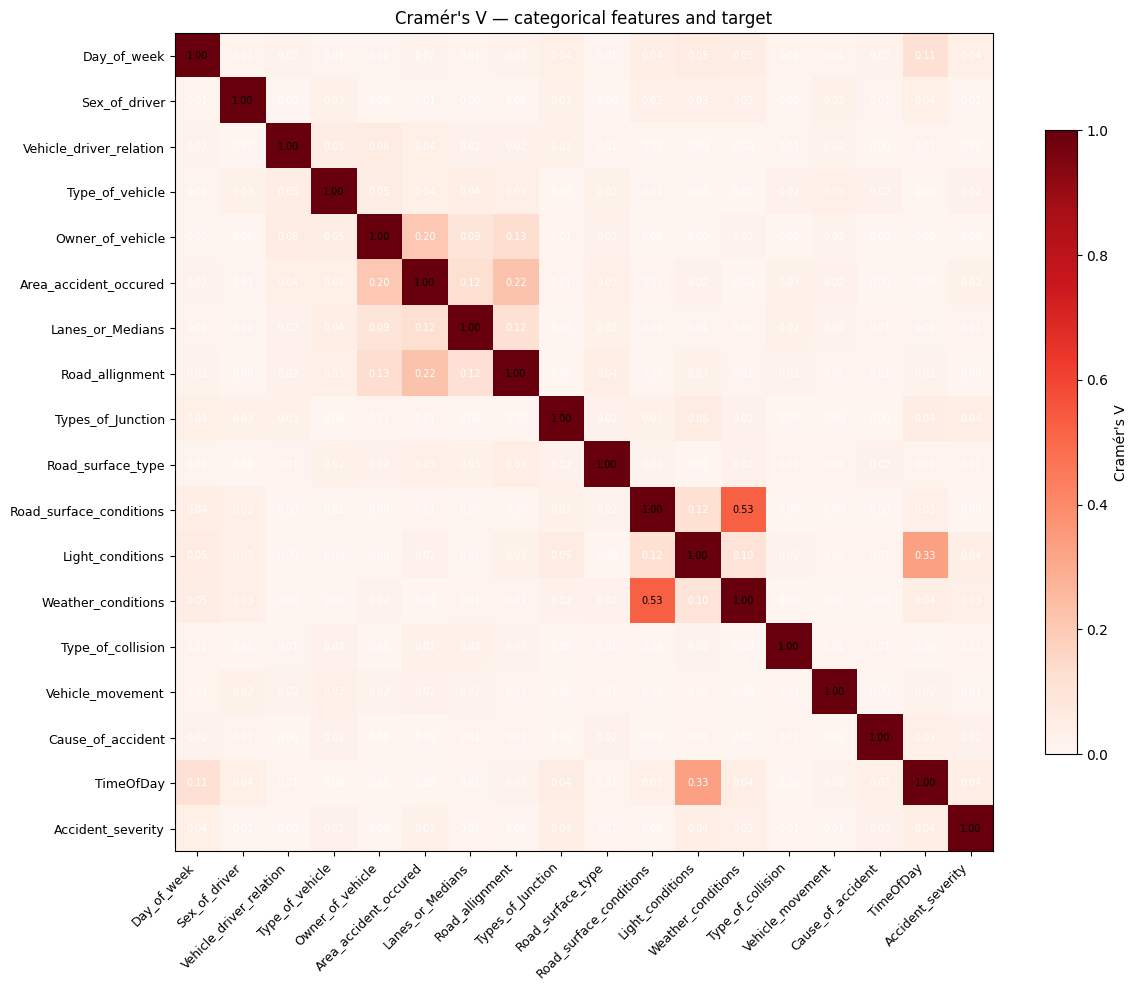

Cramér's V vs Accident_severity (ranked):
TimeOfDay                  0.042
Types_of_Junction          0.042
Light_conditions           0.040
Day_of_week                0.038
Weather_conditions         0.032
Area_accident_occured      0.024
Type_of_vehicle            0.023
Cause_of_accident          0.021
Type_of_collision          0.015
Road_surface_type          0.009
Lanes_or_Medians           0.008
Sex_of_driver              0.008
Vehicle_movement           0.005
Road_allignment            0.000
Owner_of_vehicle           0.000
Vehicle_driver_relation    0.000
Road_surface_conditions    0.000
Name: Accident_severity, dtype: float64

Top 10 categorical pairs by association (watch for redundancy):
                 feat_a                feat_b  cramers_v
Road_surface_conditions    Weather_conditions   0.525914
       Light_conditions             TimeOfDay   0.331034
  Area_accident_occured       Road_allignment   0.221225
       Owner_of_vehicle Area_accident_occured   0.203755
       

In [30]:
from scipy.stats import chi2_contingency


def cramers_v(x, y):
    """Bias-corrected Cramér's V (Bergsma & Wicher 2013). Returns 0 on degenerate tables."""
    table = pd.crosstab(x, y)
    if table.shape[0] < 2 or table.shape[1] < 2:
        return 0.0
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2_corr = max(0.0, phi2 - (r - 1) * (k - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(r_corr - 1, k_corr - 1)
    return float(np.sqrt(phi2_corr / denom)) if denom > 0 else 0.0


cat_for_assoc = [
    c for c in df.select_dtypes(include="object").columns
    if c not in {
        "Accident_severity",
        "Age_band_of_driver", "Driving_experience",
        "Service_year_of_vehicle", "Educational_level",
    }
]
cols_for_assoc = cat_for_assoc + ["Accident_severity"]

V = pd.DataFrame(np.zeros((len(cols_for_assoc), len(cols_for_assoc))),
                 index=cols_for_assoc, columns=cols_for_assoc)
for i, a in enumerate(cols_for_assoc):
    for j, b in enumerate(cols_for_assoc):
        if j < i:
            V.iloc[i, j] = V.iloc[j, i]
        elif j == i:
            V.iloc[i, j] = 1.0
        else:
            V.iloc[i, j] = cramers_v(df[a], df[b])

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(V.values, cmap="Reds", vmin=0, vmax=1)
ax.set_xticks(range(len(V.columns)))
ax.set_yticks(range(len(V.columns)))
ax.set_xticklabels(V.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(V.columns, fontsize=9)
for i in range(len(V)):
    for j in range(len(V)):
        ax.text(j, i, f"{V.iloc[i, j]:.2f}",
                ha="center", va="center",
                color="white" if V.iloc[i, j] < 0.5 else "black", fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.03, label="Cramér's V")
ax.set_title("Cramér's V — categorical features and target")
plt.tight_layout()
plt.show()

target_assoc = V["Accident_severity"].drop("Accident_severity").sort_values(ascending=False)
print("Cramér's V vs Accident_severity (ranked):")
print(target_assoc.round(3))

upper = V.where(np.triu(np.ones(V.shape, dtype=bool), k=1))
top_pairs = (upper.stack()
             .sort_values(ascending=False)
             .head(10)
             .rename("cramers_v")
             .reset_index()
             .rename(columns={"level_0": "feat_a", "level_1": "feat_b"}))
print("\nTop 10 categorical pairs by association (watch for redundancy):")
print(top_pairs.to_string(index=False))


## Feature set for modeling

Columns in `data/data_cleaned.csv` and their intended role:


In [26]:
# Print the feature contract: name, type, intended use.
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c not in ("Accident_severity",)]
int_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
int_cols = [c for c in int_cols if c not in ("Severity_code",)]

print(f"Target: Accident_severity  (string) / Severity_code (int 0-2)")
print()
print(f"Categorical features ({len(cat_cols)}):")
for c in cat_cols:
    print(f"  {c}  ({df[c].nunique()} levels)")
print()
print(f"Numeric / ordinal features ({len(int_cols)}):")
for c in int_cols:
    print(f"  {c}  (min={df[c].min()}, max={df[c].max()})")

Target: Accident_severity  (string) / Severity_code (int 0-2)

Categorical features (21):
  Day_of_week  (7 levels)
  Age_band_of_driver  (5 levels)
  Sex_of_driver  (3 levels)
  Educational_level  (7 levels)
  Vehicle_driver_relation  (4 levels)
  Driving_experience  (7 levels)
  Type_of_vehicle  (18 levels)
  Owner_of_vehicle  (5 levels)
  Service_year_of_vehicle  (6 levels)
  Area_accident_occured  (12 levels)
  Lanes_or_Medians  (7 levels)
  Road_allignment  (10 levels)
  Types_of_Junction  (8 levels)
  Road_surface_type  (6 levels)
  Road_surface_conditions  (4 levels)
  Light_conditions  (4 levels)
  Weather_conditions  (9 levels)
  Type_of_collision  (10 levels)
  Vehicle_movement  (13 levels)
  Cause_of_accident  (20 levels)
  TimeOfDay  (4 levels)

Numeric / ordinal features (9):
  Number_of_vehicles_involved  (min=1, max=7)
  Number_of_casualties  (min=1, max=8)
  Hour  (min=0, max=23)
  RushHour  (min=0, max=1)
  IsWeekend  (min=0, max=1)
  Age_band_of_driver_ord  (min=-1, m

/tmp/ipykernel_25318/3142614642.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


## Modeling notes

- **Class imbalance**: apply SMOTE on the training fold only, after train-test split.
- **Categorical encoding**: TabNet needs OrdinalEncoder + `cat_idxs`/`cat_dims`.
  Stacking (XGBoost + ExtraTrees) works with OrdinalEncoder directly.
  MLP needs OHE or learned embeddings.
- **Ordinal columns (`_ord`)**: can be fed as numeric to any model.
  The -1 sentinel is meaningful — it separates 'not on the scale' from the
  lowest ordinal value (0).
- **`Unknown` category**: treat as its own level in all encoders, not as NaN.
